# Data Science for Business
## Session 5: Databases
**Kostis Christodoulou** | Jan 2026

This notebook covers:
- DuckDB for in-memory databases
- SQL vs pandas/ 
- Apache Arrow for large-scale data
- NYC Taxi dataset analysis
- Combining Arrow + DuckDB

## 0. Install dependencies

In [ ]:
%pip install duckdb pandas pyarrow seaborn matplotlib nycflights13 --quiet

## 1. Imports

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.dataset as ds
import time

sns.set_theme(style='whitegrid')
print('OK')

OK


## 2. Databases

We store data that are too big to fit into a computer's memory and access it through a **database**.

- Databases can exist locally or remotely, in-memory or on-disk
- Most rely on **binary search trees** — eliminating half of remaining data at each search step
- Data is organised in **tables** (rows + columns), each row identified by a **unique key**
- The key difference from dataframes: databases can hold far more data and are extremely efficient at querying it

### SQL vs pandas

| SQL | pandas |
|-----|--------|
| `SELECT` columns | `df[['col1','col2']]` |
| `SELECT` expressions | `df.assign()` |
| `SELECT` aggregates | `df.agg()` |
| `WHERE` | `df.query()` / `.loc[]` |
| `GROUP BY` | `df.groupby()` |
| `ORDER BY` | `df.sort_values()` |
| `LIMIT` | `df.head()` |

## 3. Connect to DuckDB

**DuckDB** is a lightweight but powerful in-process database. It supports analytics workflows (fewer but expensive queries) rather than transactional ones, and is much faster than SQLite for data science use cases.

In [4]:
# Create an in-memory DuckDB connection
con = duckdb.connect(':memory:')
print('Connected to in-memory DuckDB')

Connected to in-memory DuckDB


## 4. Populate the database with `flights`

We load the `flights` dataset from the `nycflights13` package into DuckDB. Indexes make queries fast by specifying how data is laid out for search and aggregation.

In [5]:
flights = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/flights.csv")
airlines = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/airlines.csv")
airports = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/airports.csv")
weather = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/weather.csv")

# Register as DuckDB tables
con.register('flights', flights)
con.register('airlines',  airlines)
con.register('airports',  airports)
con.register('weather',  weather)

print('Tables:', con.execute("SHOW TABLES").df()['name'].tolist())
print(f'Flights rows: {len(flights):,}')

Tables: ['airlines', 'airports', 'flights', 'weather']
Flights rows: 336,776


## 5. Peek at the data

In [4]:
con.execute('SELECT * FROM flights LIMIT 5').df()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


## 6. Generating queries

DuckDB lets us run SQL directly. Below we replicate the dplyr examples from the slides.

### Flights with departure delay > 120 minutes

In [5]:
con.execute("""
    SELECT *
    FROM flights
    WHERE dep_delay > 120
    LIMIT 10
""").df()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,848.0,1835,853.0,1001.0,1950,851.0,MQ,3944,N942MQ,JFK,BWI,41.0,184,18,35,2013-01-01T23:00:00Z
1,2013,1,1,957.0,733,144.0,1056.0,853,123.0,UA,856,N534UA,EWR,BOS,37.0,200,7,33,2013-01-01T12:00:00Z
2,2013,1,1,1114.0,900,134.0,1447.0,1222,145.0,UA,1086,N76502,LGA,IAH,248.0,1416,9,0,2013-01-01T14:00:00Z
3,2013,1,1,1540.0,1338,122.0,2020.0,1825,115.0,B6,705,N570JB,JFK,SJU,193.0,1598,13,38,2013-01-01T18:00:00Z
4,2013,1,1,1815.0,1325,290.0,2120.0,1542,338.0,EV,4417,N17185,EWR,OMA,213.0,1134,13,25,2013-01-01T18:00:00Z
5,2013,1,1,1842.0,1422,260.0,1958.0,1535,263.0,EV,4633,N18120,EWR,BTV,46.0,266,14,22,2013-01-01T19:00:00Z
6,2013,1,1,1856.0,1645,131.0,2212.0,2005,127.0,AA,181,N323AA,JFK,LAX,336.0,2475,16,45,2013-01-01T21:00:00Z
7,2013,1,1,1934.0,1725,129.0,2126.0,1855,151.0,MQ,4255,N909MQ,JFK,BNA,154.0,765,17,25,2013-01-01T22:00:00Z
8,2013,1,1,1938.0,1703,155.0,2109.0,1823,166.0,EV,4300,N18557,EWR,RIC,68.0,277,17,3,2013-01-01T22:00:00Z
9,2013,1,1,1942.0,1705,157.0,2124.0,1830,174.0,MQ,4410,N835MQ,JFK,DCA,60.0,213,17,5,2013-01-01T22:00:00Z


### Mean departure delay by origin → destination, descending

In [6]:
mean_delay = con.execute("""
    SELECT
        origin,
        dest,
        ROUND(AVG(dep_delay), 2) AS mean_dep_delay
    FROM flights
    WHERE dep_delay IS NOT NULL
    GROUP BY origin, dest
    ORDER BY mean_dep_delay DESC
""").df()

mean_delay.head(10)

,origin,dest,mean_dep_delay
0,EWR,TYS,41.82
1,EWR,CAE,36.34
2,EWR,TUL,34.91
3,LGA,SBN,31.33
4,EWR,OKC,30.57
5,LGA,BHM,29.78
6,LGA,CAE,29.50
7,EWR,DSM,29.33
8,EWR,JAC,28.70
9,EWR,ROC,27.86


## 7. Method chaining in pandas

**Method chaining**: build up the full transformation pipeline before materialising results, keeping code readable and avoiding intermediate copies.

In [ ]:
#  running the query in SQL
import time
start = time.perf_counter()

tailnum_delay_sql = con.execute("""
SELECT
    tailnum,
    AVG(dep_delay) AS mean_dep_delay,
    AVG(arr_delay) AS mean_arr_delay,
    COUNT(*) AS n
FROM
    flights
GROUP BY
    tailnum
HAVING
    n > 100
ORDER BY
    mean_arr_delay DESC
""").df()

end = time.perf_counter()
print(f"Elapsed time: {end - start:.2f} seconds")

tailnum_delay_sql.info()
tailnum_delay_sql.head(10)

Elapsed time: 0.01 seconds
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tailnum         1200 non-null   object 
 1   mean_dep_delay  1200 non-null   float64
 2   mean_arr_delay  1200 non-null   float64
 3   n               1201 non-null   int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 37.7+ KB


,tailnum,mean_dep_delay,mean_arr_delay,n
0,N11119,32.586957,30.306569,148
1,N16919,32.385593,29.887446,251
2,N14998,29.406393,27.922018,230
3,N15910,29.275472,27.611321,280
4,N13123,29.649573,25.973451,121
5,N11192,27.473333,25.852349,154
6,N14950,26.214634,25.287805,219
7,N21130,27.025424,24.966102,126
8,N24128,24.803279,24.918033,129
9,N22971,26.474419,24.747664,230


In [ ]:
# running the query in pandas
start = time.perf_counter()

tailnum_delay = (
    flights
    .groupby('tailnum', as_index=False)
    .agg(
        mean_dep_delay=('dep_delay', 'mean'),
        mean_arr_delay=('arr_delay', 'mean'),
        n=('flight', 'count')
    )
    .query('n > 100')
    .sort_values('mean_arr_delay', ascending=False)
    .round(2)
    .reset_index(drop=True)
)

end = time.perf_counter()
print(f"Elapsed time: {end - start:.2f} seconds")

tailnum_delay.head(10)

Elapsed time: 0.07 seconds


,tailnum,mean_dep_delay,mean_arr_delay,n
0,N11119,32.59,30.31,148
1,N16919,32.39,29.89,251
2,N14998,29.41,27.92,230
3,N15910,29.28,27.61,280
4,N13123,29.65,25.97,121
5,N11192,27.47,25.85,154
6,N14950,26.21,25.29,219
7,N21130,27.03,24.97,126
8,N24128,24.80,24.92,129
9,N22971,26.47,24.75,230


## 8. Plot: departure delay vs arrival delay

Most planes manage to make up time even if they depart late.

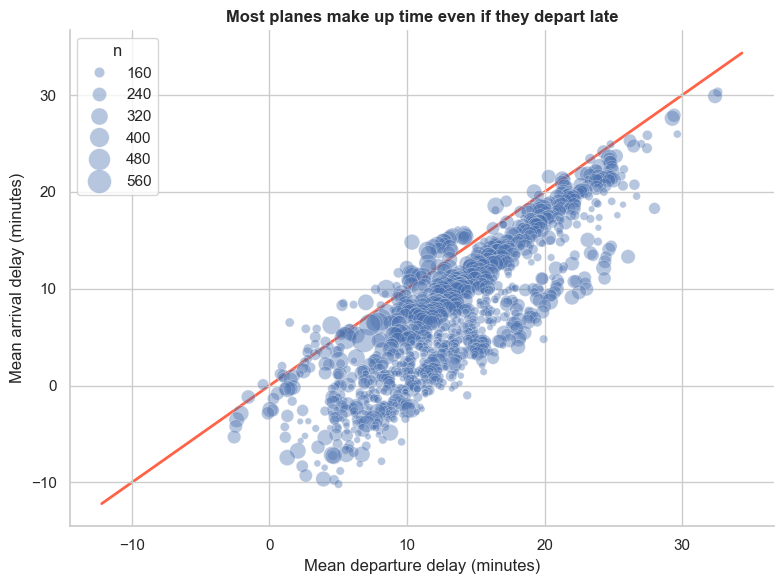

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=tailnum_delay,
    x='mean_dep_delay', y='mean_arr_delay',
    size='n', sizes=(20, 300),
    alpha=0.4, ax=ax
)

# y = x reference line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, color='tomato', linewidth=2, zorder=0)

ax.set_title('Most planes make up time even if they depart late', fontweight='bold')
ax.set_xlabel('Mean departure delay (minutes)')
ax.set_ylabel('Mean arrival delay (minutes)')
sns.despine()
plt.tight_layout()
plt.show()

## 9. Joins

pandas join methods map directly to SQL joins:

| SQL | pandas |
|-----|--------|
| `LEFT JOIN` | `df.merge(..., how='left')` |
| `INNER JOIN` | `df.merge(..., how='inner')` |
| `FULL OUTER JOIN` | `df.merge(..., how='outer')` |

In [11]:
flights_with_planes = (
    flights
    .merge(
        planes.rename(columns={'year': 'year_built'})[['tailnum','year_built','type','model']],
        on='tailnum',
        how='left'
    )
    [['year','month','day','dep_time','arr_time','carrier','flight',
      'tailnum','year_built','type','model']]
)

flights_with_planes.head(10)

,year,month,day,dep_time,arr_time,carrier,flight,tailnum,year_built,type,model
0,2013,1,1,517.0,830.0,UA,1545,N14228,1999.0,Fixed wing multi engine,737-824
1,2013,1,1,533.0,850.0,UA,1714,N24211,1998.0,Fixed wing multi engine,737-824
2,2013,1,1,542.0,923.0,AA,1141,N619AA,1990.0,Fixed wing multi engine,757-223
3,2013,1,1,544.0,1004.0,B6,725,N804JB,2012.0,Fixed wing multi engine,A320-232
4,2013,1,1,554.0,812.0,DL,461,N668DN,1991.0,Fixed wing multi engine,757-232
5,2013,1,1,554.0,740.0,UA,1696,N39463,2012.0,Fixed wing multi engine,737-924ER
6,2013,1,1,555.0,913.0,B6,507,N516JB,2000.0,Fixed wing multi engine,A320-232
7,2013,1,1,557.0,709.0,EV,5708,N829AS,1998.0,Fixed wing multi engine,CL-600-2B19
8,2013,1,1,557.0,838.0,B6,79,N593JB,2004.0,Fixed wing multi engine,A320-232
9,2013,1,1,558.0,753.0,AA,301,N3ALAA,NaN,NaN,NaN


## 10. Inspecting the SQL DuckDB generates


In [ ]:
# Run the tailnum_delay logic in DuckDB SQL and inspect the query
query = """
    SELECT
        tailnum,
        ROUND(AVG(dep_delay), 2) AS mean_dep_delay,
        ROUND(AVG(arr_delay), 2) AS mean_arr_delay,
        COUNT(*) AS n
    FROM flights
    GROUP BY tailnum
    HAVING COUNT(*) > 100
    ORDER BY mean_arr_delay DESC
"""

print('SQL query:')
print(query)
con.execute(query).df().head(10) #the query is run and the results are pulled into a pandas dataframe

SQL query:

    SELECT
        tailnum,
        ROUND(AVG(dep_delay), 2) AS mean_dep_delay,
        ROUND(AVG(arr_delay), 2) AS mean_arr_delay,
        COUNT(*) AS n
    FROM flights
    GROUP BY tailnum
    HAVING COUNT(*) > 100
    ORDER BY mean_arr_delay DESC



,tailnum,mean_dep_delay,mean_arr_delay,n
0,N11119,32.59,30.31,148
1,N16919,32.39,29.89,251
2,N14998,29.41,27.92,230
3,N15910,29.28,27.61,280
4,N13123,29.65,25.97,121
5,N11192,27.47,25.85,154
6,N14950,26.21,25.29,219
7,N21130,27.03,24.97,126
8,N24128,24.80,24.92,129
9,N22971,26.47,24.75,230


## 11. Lexical vs. logical order of SQL operations

SQL is written in a different order than it executes:

```
Written order:   SELECT → FROM → WHERE → GROUP BY → HAVING → ORDER BY → LIMIT
Execution order: FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY → LIMIT
```

pandas method chaining follows the **logical** order, which is more intuitive:

```python
(
    df                          # FROM
    .query('condition')         # WHERE
    .groupby('col')             # GROUP BY
    .agg(n=('col','count'))     # SELECT aggregate
    .query('n > 100')           # HAVING
    .sort_values('col')         # ORDER BY
    .head(10)                   # LIMIT
)
```

---
# Apache Arrow

> A multi-language toolbox for accelerated data interchange and in-memory processing

- Implementations in R, Python, C++, Rust, Julia, JavaScript
- Shares data between applications **without copy/convert** — just passes pointers
- Structures data efficiently in-memory; provides compute engines to process it
- Used when data is **too large to fit in memory**, stored as multiple files on disk

## 12. `open_dataset()` — NYC Taxi data

The NYC TLC publishes ~10 years of taxi trip records as Parquet files (~37GB total, ~1.7 billion rows).

Arrow scans the folder, reads metadata, and creates a dataset object almost instantly — **it does not load the data into memory.**

```
Download the data first:
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
```

Update `NYC_TAXI_PATH` below to wherever you saved the parquet files.

In [2]:
import pyarrow.dataset as ds

NYC_TAXI_PATH = '/Users/kostischristodoulou/Library/CloudStorage/Dropbox/nyc-taxi'  # <-- update this path


start = time.time()
nyc_taxi = ds.dataset(NYC_TAXI_PATH, format='parquet', partitioning='hive')
elapsed = time.time() - start

print(f'Opened dataset in {elapsed:.2f}s')
print(f'Schema fields: {len(nyc_taxi.schema)}')
print(f'Row count: {nyc_taxi.count_rows():,}')  # scans footers only, still fast
print()
print(nyc_taxi.schema)

Opened dataset in 0.05s
Schema fields: 24
Row count: 1,672,590,319

vendor_name: string
pickup_datetime: timestamp[ms]
dropoff_datetime: timestamp[ms]
passenger_count: int64
trip_distance: double
pickup_longitude: double
pickup_latitude: double
rate_code: string
store_and_fwd: string
dropoff_longitude: double
dropoff_latitude: double
payment_type: string
fare_amount: double
extra: double
mta_tax: double
tip_amount: double
tolls_amount: double
total_amount: double
improvement_surcharge: double
congestion_surcharge: double
pickup_location_id: int64
dropoff_location_id: int64
year: int32
month: int32


### Peek at the Arrow dataset

In [3]:
# Take a small sample without loading everything
(
    nyc_taxi
    .to_table(columns=['passenger_count','trip_distance','total_amount'], filter=ds.field('year') == 2019)
    .slice(0, 10)                # take only first 10 rows
    .to_pandas()
)

,passenger_count,trip_distance,total_amount
0,1,0.90,6.96
1,1,3.07,15.96
2,1,0.71,5.30
3,1,0.95,7.56
4,1,1.00,7.80
5,2,2.83,12.30
6,1,2.47,12.80
7,1,2.28,11.16
8,1,0.70,6.36
9,1,0.65,5.30


## 13. command chaining with Arrow

Using `pyarrow` + pandas method chaining

**Query:** for rides since 2015, count total and shared trips per year, compute % shared.

In [ ]:
start = time.time()

# We're building up a result step-by-step using method chaining.
# Each line does one thing and passes its result to the next — read top to bottom.

pct_shared = (
    nyc_taxi                              # Start with our full NYC taxi dataset (Arrow/Parquet format)
    .to_table(
        columns=['year','passenger_count'], # Only load these 2 columns — faster than loading everything
        filter=ds.field('year') >= 2015    # Filter BEFORE loading into memory (very efficient on large data)
    )
    .to_pandas()                           # Convert from Arrow table to a pandas DataFrame so we can use pandas tools

    .groupby('year', as_index=False)       # Group rows by year; as_index=False keeps 'year' as a regular column (not the index)

    .agg(
        all_trips=('passenger_count', 'count'),              # Count every row per year → total trips
        shared_trips=('passenger_count', lambda x: (x > 1).sum())  # Count rows where passenger_count > 1 → shared rides
        #                                                              lambda x: means "for each year's group of values, do this"
    )

    .assign(
        # Create a new column on the fly without overwriting the DataFrame
        # lambda df: means "take the current DataFrame and compute this"
        pct_shared=lambda df: (df['shared_trips'] / df['all_trips'] * 100).round(2)  # shared as % of total, rounded to 2 decimal places
    )

    .sort_values('year')                   # Sort rows oldest → newest year so the output is easy to read
)

elapsed = time.time() - start
print(f'Query completed in {elapsed:.2f}s')
pct_shared

# the bottleneck is .to_pandas() which materialises the full filtered table into memory before aggregating. 
# The fix is to push the aggregation down into DuckDB before pulling to pandas


Query completed in 30.30s


,year,all_trips,shared_trips,pct_shared
0,2015,146112989,43081091,29.48
1,2016,131165043,38163870,29.10
2,2017,113495512,32296166,28.46
3,2018,102797401,28796633,28.01
4,2019,84147003,23515989,27.95
5,2020,23837487,5837960,24.49
6,2021,29423923,7221844,24.54
7,2022,5270005,1211071,22.98


In [4]:
start = time.time()

pct_shared = (
    duckdb.arrow(nyc_taxi)  # zero-copy handoff from Arrow to DuckDB
    .query('nyc_taxi', """
        SELECT
            year,
            COUNT(*) AS all_trips,
            SUM(CASE WHEN passenger_count > 1 THEN 1 ELSE 0 END) AS shared_trips,
            ROUND(100.0 * SUM(CASE WHEN passenger_count > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_shared
        FROM nyc_taxi
        WHERE year >= 2015
        GROUP BY year
        ORDER BY year
    """)
    .df()
)

elapsed = time.time() - start
print(f'Query completed in {elapsed:.2f}s')
pct_shared

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Query completed in 2.30s


,year,all_trips,shared_trips,pct_shared
0,2015,146112989,43081091.0,29.48
1,2016,131165043,38163870.0,29.10
2,2017,113495512,32296166.0,28.46
3,2018,102797401,28796633.0,28.01
4,2019,84393604,23515989.0,27.86
5,2020,24647055,5837960.0,23.69
6,2021,30902618,7221844.0,23.37
7,2022,5443246,1211071.0,22.25


## 14. Exercise 1 — Rides per month in 2019

Calculate the total number of rides for every month in 2019.

In [30]:
start = time.time()

rides_2019 = (
    nyc_taxi
    .to_table(
        columns=['year','month'],
        filter=ds.field('year') == 2019
    )
    .to_pandas()
    .groupby('month', as_index=False)
    .agg(n=('month', 'count'))
    .sort_values('month')
    .reset_index(drop=True)
)

print(f'Done in {time.time()-start:.2f}s')
rides_2019

Done in 0.69s


,month,n
0,1,7667255
1,2,7018750
2,3,7832035
3,4,7432826
4,5,7564884
5,6,6940489
6,7,6310134
7,8,6072851
8,9,6567396
9,10,7213588


In [31]:
start = time.time()

rides_2019 = (
    duckdb.arrow(nyc_taxi)
    .query('nyc_taxi', """
        SELECT
            month,
            COUNT(*) AS n
        FROM nyc_taxi
        WHERE year = 2019
        GROUP BY month
        ORDER BY month
    """)
    .df()
)

print(f'Done in {time.time()-start:.2f}s')
rides_2019

Done in 0.45s


,month,n
0,1,7667255
1,2,7018750
2,3,7832035
3,4,7432826
4,5,7564884
5,6,6940489
6,7,6310134
7,8,6072851
8,9,6567396
9,10,7213588


## 15. Exercise 2 — Longest taxi ride per month in 2019

Find the distance travelled by the longest recorded taxi ride for each month in 2019.

In [32]:
start = time.time()

longest_2019 = (
    nyc_taxi
    .to_table(
        columns=['year','month','trip_distance'],
        filter=ds.field('year') == 2019
    )
    .to_pandas()
    .groupby('month', as_index=False)
    .agg(longest_trip=('trip_distance', 'max'))
    .sort_values('month')
    .reset_index(drop=True)
)

print(f'Done in {time.time()-start:.2f}s')
longest_2019

Done in 0.82s


,month,longest_trip
0,1,831.80
1,2,701.50
2,3,237.17
3,4,830.90
4,5,401.40
5,6,45977.22
6,7,311.56
7,8,601.60
8,9,603.50
9,10,307.95


In [33]:
start = time.time()

longest_2019 = (
    duckdb.arrow(nyc_taxi)
    .query('nyc_taxi', """
        SELECT
            month,
            MAX(trip_distance) AS longest_trip
        FROM nyc_taxi
        WHERE year = 2019
        GROUP BY month
        ORDER BY month
    """)
    .df()
)

print(f'Done in {time.time()-start:.2f}s')
longest_2019

Done in 0.51s


,month,longest_trip
0,1,831.80
1,2,701.50
2,3,237.17
3,4,830.90
4,5,401.40
5,6,45977.22
6,7,311.56
7,8,601.60
8,9,603.50
9,10,307.95


## 16. Mean tip percentage by number of passengers

Arrow and DuckDB work together seamlessly. You can switch between engines mid-pipeline:
- Use **Arrow** to scan/filter large on-disk datasets efficiently
- Hand off to **DuckDB** for complex SQL operations (window functions, joins, etc.)

This avoids loading the full dataset into memory.

In [ ]:
start = time.time()

tip_by_passengers = (
    duckdb.arrow(nyc_taxi)  # zero-copy handoff from Arrow to DuckDB 
    .query('nyc_taxi', """
        SELECT
            passenger_count,
            ROUND(AVG(100.0 * tip_amount / total_amount), 2) AS mean_tip_pct,
            COUNT(*) AS n
        FROM nyc_taxi
        WHERE total_amount > 10
        GROUP BY passenger_count
        ORDER BY mean_tip_pct DESC
    """)
    .df()
)

print(f"Done in {time.time() - start:.2f}s")
tip_by_passengers

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done in 8.03s


,passenger_count,mean_tip_pct,n
0,155,51.64,1
1,225,18.75,1
2,36,18.28,1
3,112,16.67,1
4,51,16.26,1
5,15,15.66,2
6,58,15.26,2
7,137,15.09,1
8,158,13.85,1
9,61,13.85,1


### Visualise: mean tip % by passenger count

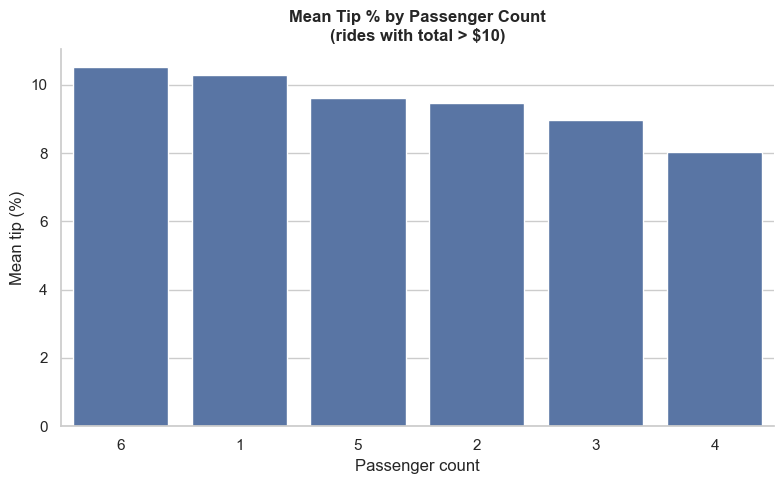

In [8]:
plot_data = (
    tip_by_passengers
    .dropna(subset=['passenger_count'])
    .query('passenger_count > 0 and passenger_count <= 6')
    .assign(passenger_count=lambda df: df['passenger_count'].astype(int).astype(str))
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_data, x='passenger_count', y='mean_tip_pct', ax=ax)
ax.set_title('Mean Tip % by Passenger Count\n(rides with total > $10)', fontweight='bold')
ax.set_xlabel('Passenger count')
ax.set_ylabel('Mean tip (%)')
sns.despine()
plt.tight_layout()
plt.show()

## Distribution of passengers by year... How many rides have 0, 1, 2, etc passengers?

In [18]:
start = time.time()

passenger_dist = (
    duckdb.arrow(nyc_taxi)  # zero-copy handoff from Arrow to DuckDB
    .query('nyc_taxi', """
        SELECT
            year,
            CASE 
                WHEN passenger_count = 0 THEN '0'
                WHEN passenger_count = 1 THEN '1'
                WHEN passenger_count = 2 THEN '2'
                WHEN passenger_count = 3 THEN '3'
                WHEN passenger_count = 4 THEN '4'
                WHEN passenger_count = 5 THEN '5'
                WHEN passenger_count = 6 THEN '6'
                ELSE 'other'
            END AS passenger_group,
            COUNT(*) AS n_rides,
            ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY year), 2) AS pct_rides
        FROM nyc_taxi
        WHERE year >= 2015  -- adjust as needed
        GROUP BY year, passenger_group
        ORDER BY year, passenger_group
    """)
    .df()
)




print(f"Done in {time.time() - start:.2f}s")
passenger_dist

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done in 2.34s


,year,passenger_group,n_rides,pct_rides
0,2015,0,40853,0.03
1,2015,1,102991045,70.49
2,2015,2,20901372,14.30
3,2015,3,6135107,4.20
4,2015,4,2981071,2.04
...,...,...,...,...
59,2022,3,188212,3.46
60,2022,4,76439,1.40
61,2022,5,110380,2.03
62,2022,6,72699,1.34


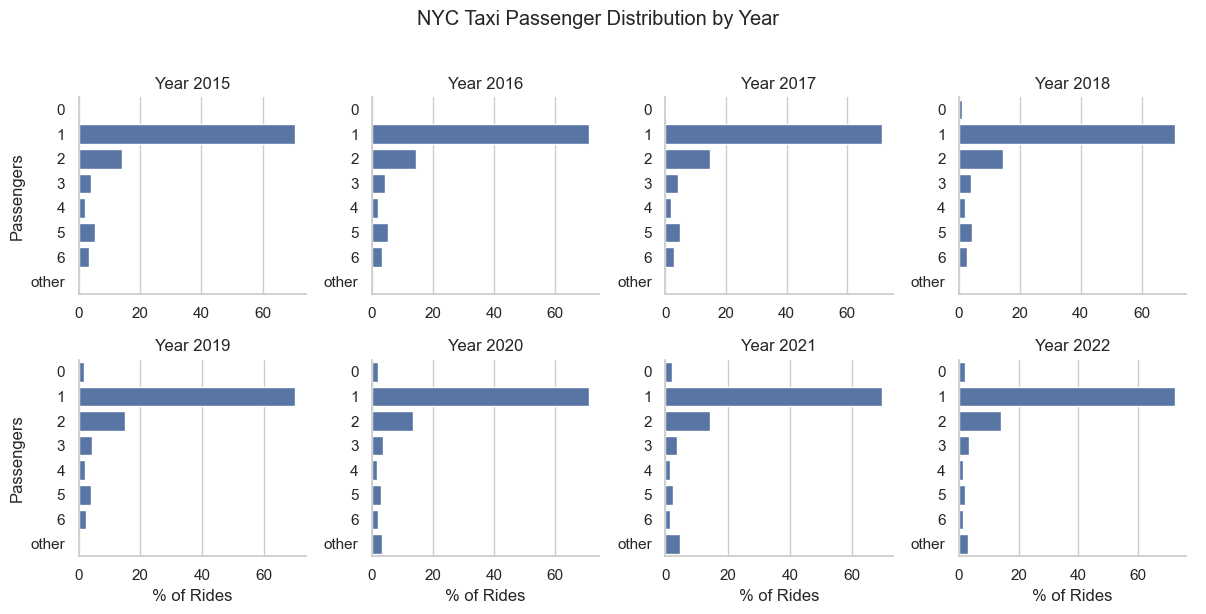

In [19]:
g = sns.catplot(
    data=passenger_dist,
    kind='bar',
    x='pct_rides', y='passenger_group', col='year',
    col_wrap=4, height=3, aspect=1, errorbar=None,  # facets wrap nicely
    sharex=False, sharey=False  # color by group
)
g.set_axis_labels('% of Rides', 'Passengers')
g.set_titles('Year {col_name}')
g.figure.suptitle('NYC Taxi Passenger Distribution by Year', y=1.02)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


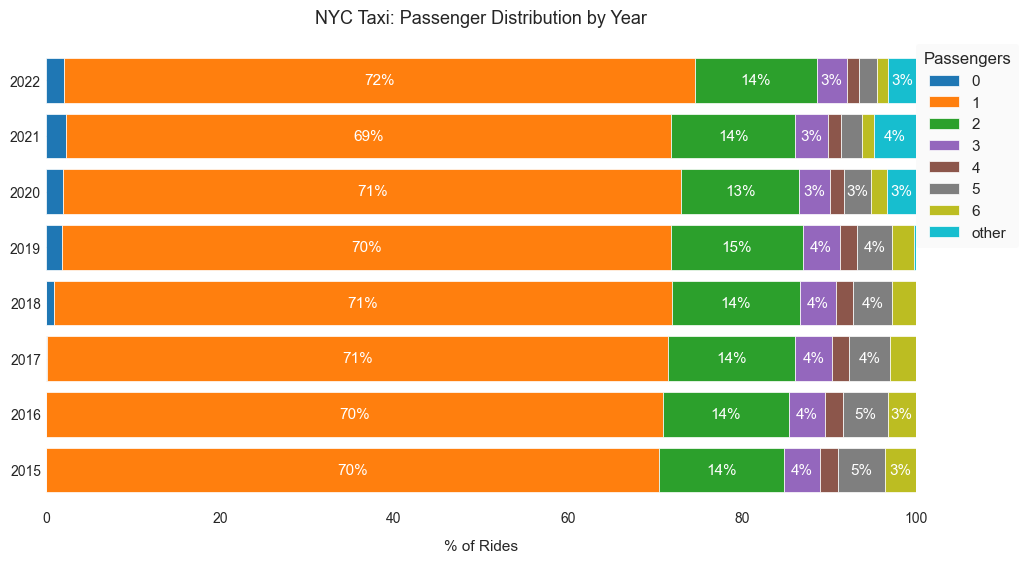

In [50]:
# Pivot to wide: rows=years, cols=passenger_groups, values=pct
pivot_pct = passenger_dist.pivot(index='year', columns='passenger_group', values='pct_rides').fillna(0)


fig, ax = plt.subplots(figsize=(12, 6))
pivot_pct.plot(kind='barh', stacked=True, ax=ax, colormap='tab10', width=0.8, edgecolor='white', linewidth=0.5)

n_years = len(pivot_pct)
n_groups = len(pivot_pct.columns)
rects = ax.patches

for i, rect in enumerate(rects):
    group_idx = i // n_years
    year_idx  = i % n_years
    group = pivot_pct.columns[group_idx]
    pct = pivot_pct.iloc[year_idx][group]
    if pct >= 3:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_y() + rect.get_height() / 2,
            f'{int(pct)}%',
            ha='center', va='center',
            color='white', fontsize=11
        )

ax.set_xlabel('% of Rides', fontsize=11, labelpad=10)
ax.set_ylabel('')
ax.set_title('NYC Taxi: Passenger Distribution by Year', fontsize=13, pad=15)
ax.set_xlim(0, 100)


fig.patch.set_facecolor('white')

# White gridlines like ggplot
ax.xaxis.grid(True, color='white', linewidth=1.2, zorder=0)
ax.set_axisbelow(True)

# Clean spines
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', length=0, labelsize=10)

ax.legend(title='Passengers', bbox_to_anchor=(1.0, 1), loc='upper left',
          borderpad=0.5, borderaxespad=0, frameon=True, framealpha=1,
          edgecolor='none', facecolor='#FAFAFA')

plt.subplots_adjust(right=0.85)
plt.show()


## Resources

- [SQL Murder Mystery](https://mystery.knightlab.com/) — learn SQL by solving a crime
- [Select Star SQL](https://selectstarsql.com/) — interactive SQL tutorial
- [A Beginner's Guide to SQL Order of Operations](https://blog.jooq.org/a-beginners-guide-to-the-true-order-of-sql-operations/)
- [Bigger data with Arrow and DuckDB](https://jthomasmock.github.io/bigger-data/)
- [Apache Arrow docs](https://arrow.apache.org/docs/python/)
- [DuckDB Python docs](https://duckdb.org/docs/api/python/overview)